# SPY: first real-market test

Independent from CGB. This notebook presents the completed frozen SPY experiment and its reproducible source. It uses real five-minute EODHD bars through Fractal’s data connection; it does not run Fractal’s complete six-notebook strategy.

The initial result is weak directional evidence: the one-hour mixture trails price-only, and its advantage over a constant forecast has an uncertainty interval crossing zero. See [the full report](REPORT.md) for definitions and interpretation.

Data and model fitting were executed by `run_study.py`. The read-only result cells below were run against those saved outputs; embedded figures are the completed run’s files. Download/refit instructions are intentionally unexecuted.

In [1]:
from pathlib import Path
import json
import pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'protocol.json').exists():
    ROOT = ROOT / 'research' / 'spy_eodhd'
protocol = json.loads((ROOT / 'protocol.json').read_text())
split = json.loads((ROOT / 'split.json').read_text())['sessions']
print('Symbol:', protocol['symbol'])
print('Primary horizon:', protocol['primary_horizon_minutes'], 'minutes')
for name, sessions in split.items():
    print(name, len(sessions), sessions[0], 'to', sessions[-1])


Symbol: SPY.US
Primary horizon: 60 minutes
train 144 2025-09-26 to 2026-05-01
cal 48 2026-05-04 to 2026-07-14
test 49 2026-07-15 to 2026-09-25


## Data quality and causality

Provider timestamps are bar starts; decisions occur five minutes later. These historical bars do not contain measured receipt timestamps. Whole-session completeness is an explicitly retrospective cohort rule. Ten scheduled sessions, including both early closes, fail it. No forward fill, fabricated spreads or signed trades are used.

In [2]:
quality = pd.read_csv(ROOT / 'session-quality.csv')
print('Scheduled:', len(quality), 'Retained:', int(quality.retained.sum()))
print(quality.loc[~quality.retained, ['session', 'expected_bars', 'valid_bars']].to_string(index=False))


Scheduled: 251 Retained: 241
   session  expected_bars  valid_bars
2025-11-28             42          40
2025-12-24             42          40
2026-01-21             78          77
2026-02-02             78          27
2026-02-06             78          76
2026-04-29             78          77
2026-05-12             78          77
2026-08-18             78          76
2026-08-20             78          77
2026-08-26             78          76


## Architecture and comparisons

The model fits prior-price measurements, five observed states, state age, session clock, unsigned bar volume and a clearly approximate bar VWAP reference. TRAIN supplies heads, scaling, transitions and scenarios; CAL supplies mixture weights. TEST is frozen. The targets are down, neutral or up relative to the origin-specific volatility band, with future endpoint and adverse-extrema summaries.

In [3]:
metrics = pd.read_csv(ROOT / 'metrics.csv')
print(metrics.pivot(index='model', columns='horizon_minutes', values='log_loss').round(6).to_string())


horizon_minutes       60        120       240
model                                        
clock_only       1.097815  1.100631  1.089180
direct_full      1.097375  1.096544  1.089310
local            1.097111  1.093800  1.086312
mixture          1.096452  1.093547  1.085388
momentum_only    1.099661  1.094716  1.092582
price_only       1.095584  1.089862  1.088407
structural       1.096408  1.094049  1.085847
supervised       1.097375  1.096544  1.089310
train_frequency  1.098091  1.099169  1.089483


## Held-out probability scores

Lower log loss is better. Differences are small; each session has equal scoring weight.

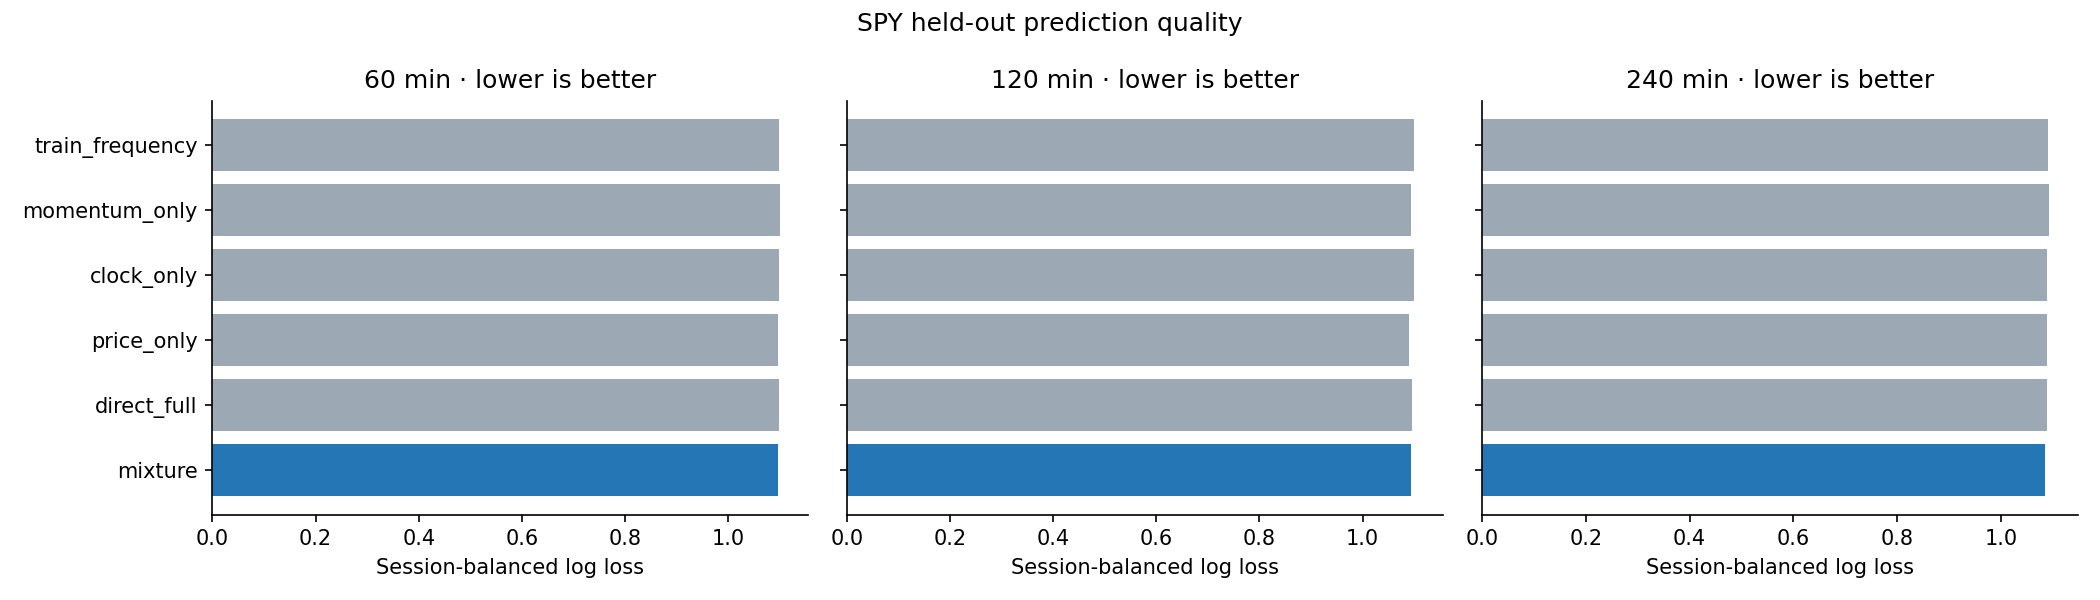

In [4]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/heldout-scores.png')))


In [5]:
comparisons = pd.read_csv(ROOT / 'comparisons.csv')
print(comparisons.query('horizon_minutes == 60')[['baseline','mean','low','high']].round(6).to_string(index=False))


       baseline      mean       low     high
train_frequency -0.001640 -0.007402 0.003892
  momentum_only -0.003209 -0.009144 0.002735
     clock_only -0.001363 -0.010114 0.006620
     price_only  0.000868 -0.004714 0.006729
    direct_full -0.000923 -0.002552 0.000598


## Incremental evidence

Intervals crossing zero do not distinguish a stable score improvement on this sample. Five-session blocks preserve some serial dependence; the intervals do not cover all selection uncertainty.

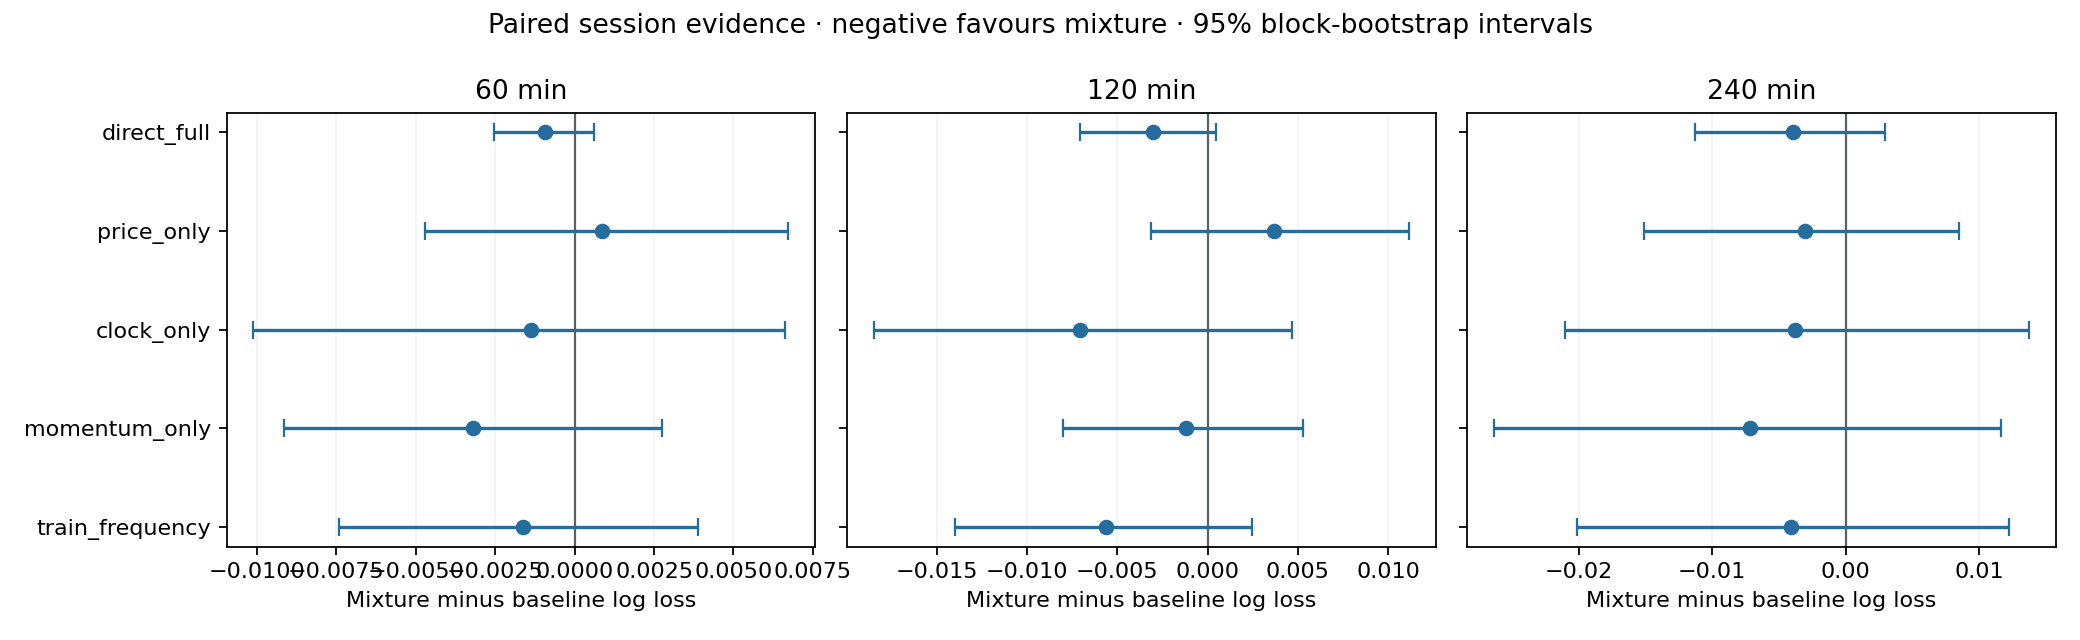

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/incremental-evidence.png')))


## Changes during TEST

This is descriptive monitoring of the untouched evaluation, not a tuning signal applied back to the same period.

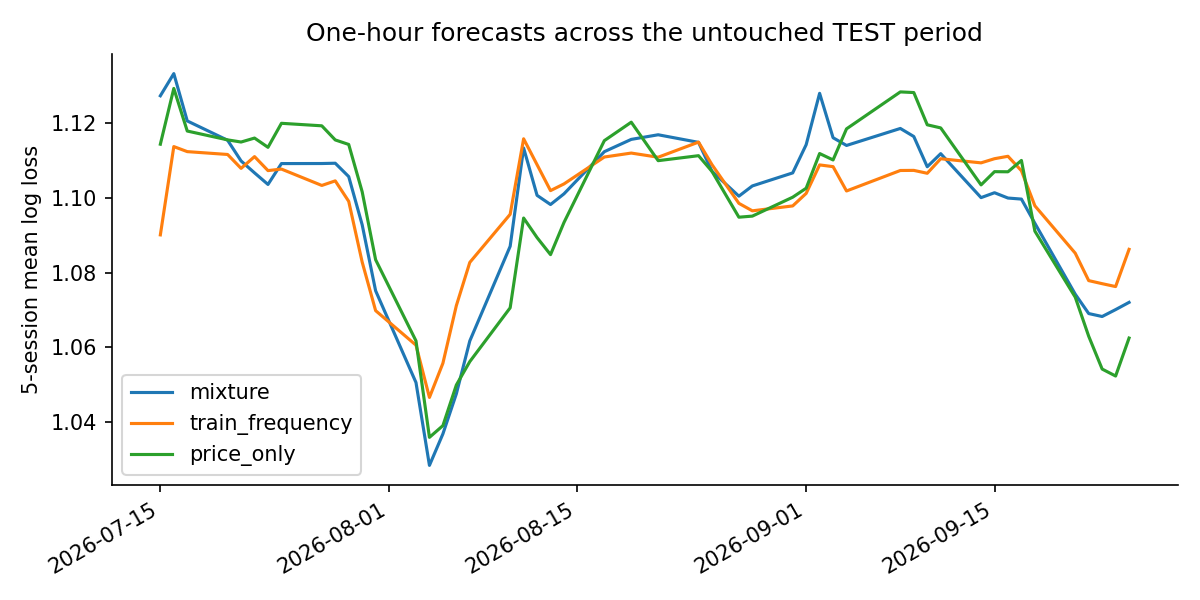

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/test-loss-through-time.png')))


In [8]:
print(pd.read_csv(ROOT / 'risk-metrics.csv').round(4).to_string(index=False))
print(json.dumps(json.loads((ROOT / 'fit-metadata.json').read_text()), indent=2))


 horizon_minutes  rows  endpoint_mae_cents  endpoint_80_interval_coverage  long_adverse_q80_coverage  short_adverse_q80_coverage
              60  2646             93.9389                         0.7940                     0.8122                      0.7770
             120  2058            128.5669                         0.8066                     0.8183                      0.7677
             240   882            192.8518                         0.7834                     0.8277                      0.7517
{
  "60": {
    "mixture_weights": [
      0.3239942855470205,
      2.222614453595284e-16,
      0.6760057144529794
    ],
    "state_ml_weight": 0.22607294152839236,
    "fit_last_origin": "2026-05-01T19:00:00+00:00",
    "available_after": "2026-07-14T20:00:00+00:00",
    "eligible_sessions": {
      "train": 144,
      "cal": 48,
      "test": 49
    }
  },
  "120": {
    "mixture_weights": [
      0.41183586384224447,
      1.5899824859499923e-16,
      0.5881641361577553
  

## Reliability and path uncertainty

The bins are origin-level descriptive summaries, with at least twenty origins. Endpoint coverage near 80% does not by itself demonstrate directional or incremental path-risk skill.

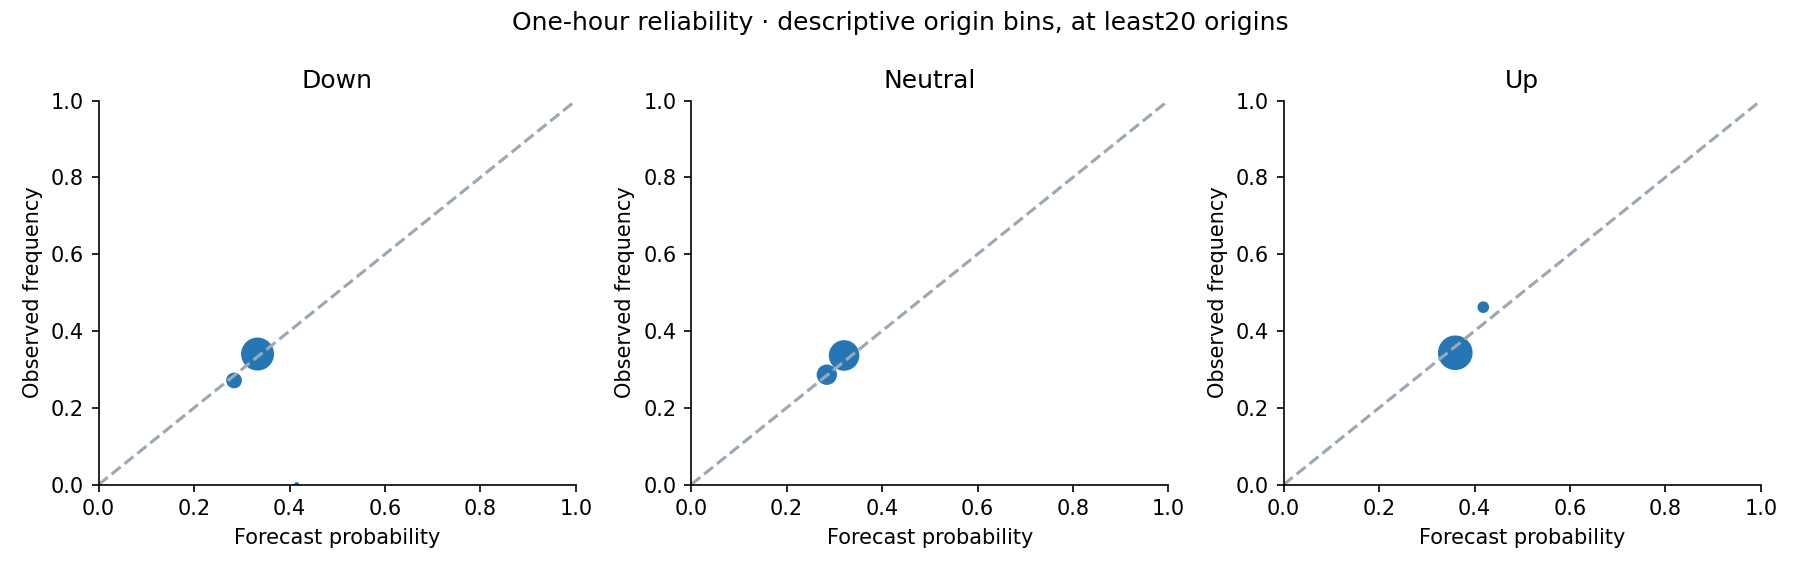

In [9]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/reliability.png')))


## Local market replay

The interactive chart is shown in the conversation. `private/chart-data.json` contains the first retained TEST session, 15 July 2026, initially cut at noon. Unsigned share volume replaces the unavailable signed-flow pane. The original market rows, fitted model and individual forecasts remain local and ignored by Git. `ui/verify_ui.cjs` tests the reusable chart source.

## Basket study next

[basket-universe.json](basket-universe.json) records 100 exact configured symbols from the Fractal source. The planned US-listed Q2 adaptation has 51 long-leg and 17 short-leg names. No basket performance is claimed here. Separate fixed exposure, past-only risk weighting, regime-conditioned evaluation and dynamic selection. [Read the design](basket-design.md).

## Reproduction commands

Run these only when deliberately recreating the dataset/fit. Set `EODHD_API_KEY` locally or pass the existing Fractal directory. Never paste a token into this notebook. Preserve the protocol and establish a new experiment identity for changes after inspecting TEST.

In [ ]:
# Example commands from the study folder; intentionally unexecuted here.
# python fetch_data.py --fractal-dir C:/path/to/fractal-x
# python run_study.py --raw private/raw/SPY.US-5m.json
# node ui/verify_ui.cjs
